# **Import data and lib**

In [ ]:
!pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
bank_marketing = fetch_ucirepo(id=222)

# data (as pandas dataframes)
X = bank_marketing.data.features
y = bank_marketing.data.targets

# metadata
print(bank_marketing.metadata)

# variable information
print(bank_marketing.variables)


{'uci_id': 222, 'name': 'Bank Marketing', 'repository_url': 'https://archive.ics.uci.edu/dataset/222/bank+marketing', 'data_url': 'https://archive.ics.uci.edu/static/public/222/data.csv', 'abstract': 'The data is related with direct marketing campaigns (phone calls) of a Portuguese banking institution. The classification goal is to predict if the client will subscribe a term deposit (variable y).', 'area': 'Business', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 45211, 'num_features': 16, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Occupation', 'Marital Status', 'Education Level'], 'target_col': ['y'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2014, 'last_updated': 'Fri Aug 18 2023', 'dataset_doi': '10.24432/C5K306', 'creators': ['S. Moro', 'P. Rita', 'P. Cortez'], 'intro_paper': {'ID': 277, 'type': 'NATIVE', 'title': 'A data-driven approach to predict the s

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

In [ ]:
X

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,NaN
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,NaN
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,NaN


In [ ]:
y

,y
0,no
1,no
2,no
3,no
4,no
...,...
45206,yes
45207,yes
45208,yes
45209,no


In [ ]:
Bn = pd.concat([X, y], axis=1)
display(Bn.head())

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no


In [ ]:
Bn.shape #shape very updated (17 feature)

(45211, 17)

# Make Analysis

In [ ]:
Bn.isna().sum()

,0
age,0
job,288
marital,0
education,1857
default,0
balance,0
housing,0
loan,0
contact,13020
day_of_week,0


In [ ]:
Bn['job'].unique()

array(['management', 'technician', 'entrepreneur', 'blue-collar', nan,
       'retired', 'admin.', 'services', 'self-employed', 'unemployed',
       'housemaid', 'student'], dtype=object)

In [ ]:
Bn.drop(columns=['day_of_week','month','poutcome'], inplace=True)
Bn

,age,job,marital,education,default,balance,housing,loan,contact,duration,campaign,pdays,previous,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,261,1,-1,0,no
1,44,technician,single,secondary,no,29,yes,no,NaN,151,1,-1,0,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,76,1,-1,0,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,92,1,-1,0,no
4,33,NaN,single,NaN,no,1,no,no,NaN,198,1,-1,0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,977,3,-1,0,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,456,2,-1,0,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,1127,5,184,3,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,508,4,-1,0,no


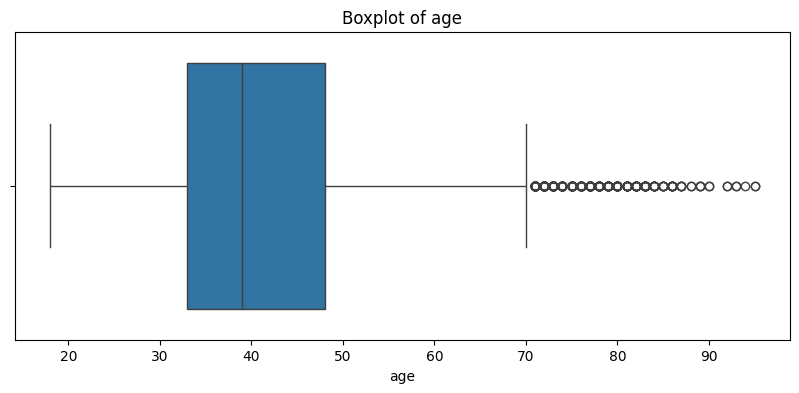

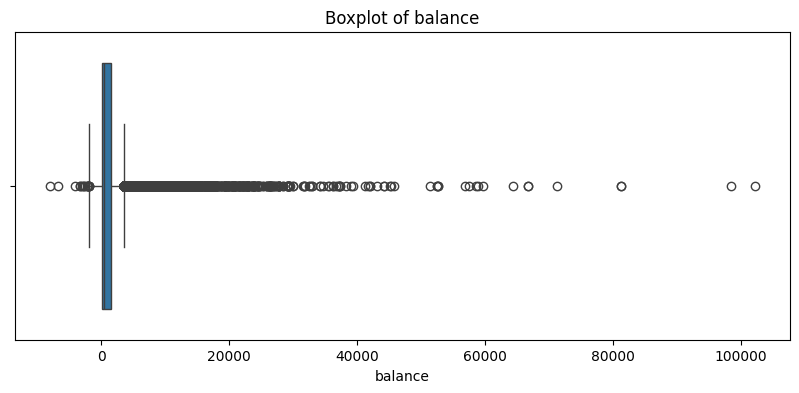

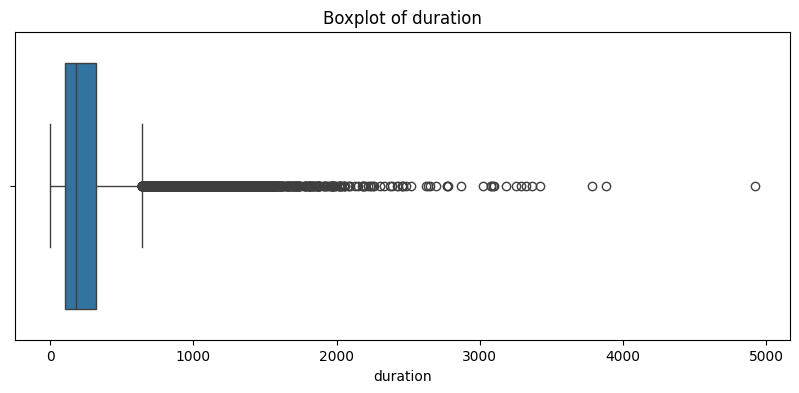

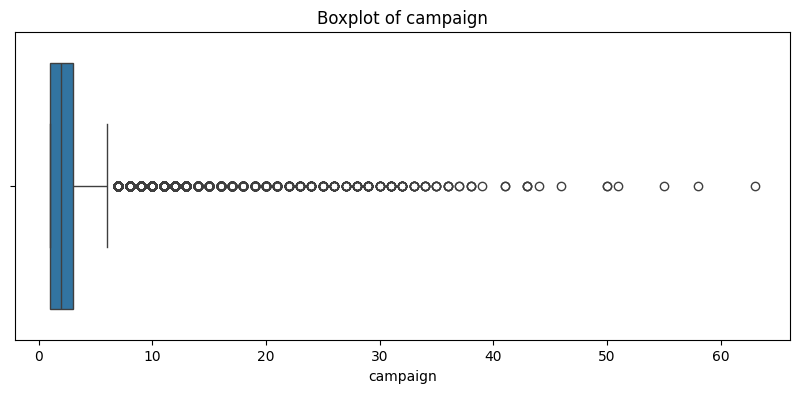

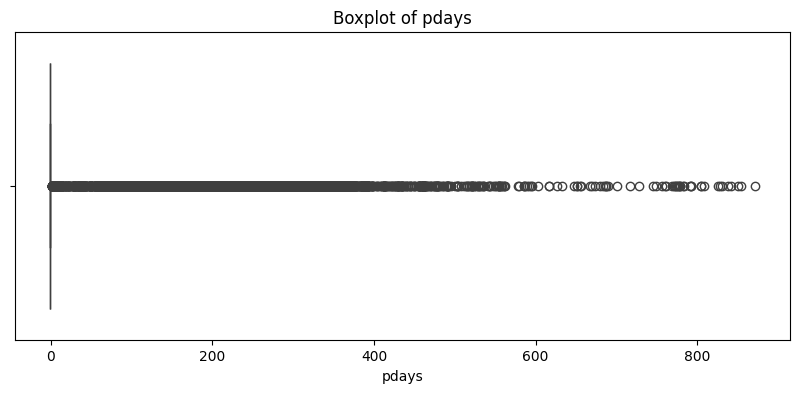

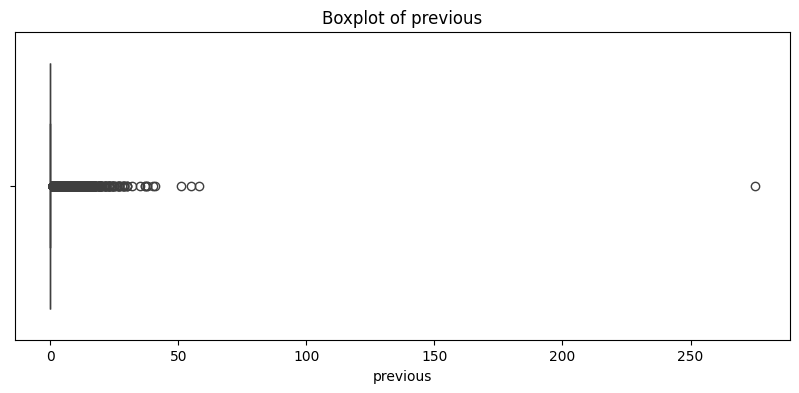

In [ ]:
# Select only numeric columns for boxplots
numeric_cols = Bn.select_dtypes(include=np.number).columns

# Create boxplots for each numeric column in Bn
for col in numeric_cols:
    plt.figure(figsize=(10, 4))
    sns.boxplot(x=Bn[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [ ]:
Bn.isna().sum()

,0
age,0
job,288
marital,0
education,1857
default,0
balance,0
housing,0
loan,0
contact,13020
duration,0


In [ ]:
Bn.drop(columns=['contact'], inplace=True)
Bn

,age,job,marital,education,default,balance,housing,loan,duration,campaign,pdays,previous,y
0,58,management,married,tertiary,no,2143,yes,no,261,1,-1,0,no
1,44,technician,single,secondary,no,29,yes,no,151,1,-1,0,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,76,1,-1,0,no
3,47,blue-collar,married,NaN,no,1506,yes,no,92,1,-1,0,no
4,33,NaN,single,NaN,no,1,no,no,198,1,-1,0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,977,3,-1,0,yes
45207,71,retired,divorced,primary,no,1729,no,no,456,2,-1,0,yes
45208,72,retired,married,secondary,no,5715,no,no,1127,5,184,3,yes
45209,57,blue-collar,married,secondary,no,668,no,no,508,4,-1,0,no


In [ ]:
categorical_cols = Bn.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"Unique values in column ['{col}']:")
    print(Bn[col].unique())
    print("-" * 20)

Unique values in column ['job']:
['management' 'technician' 'entrepreneur' 'blue-collar' nan 'retired'
 'admin.' 'services' 'self-employed' 'unemployed' 'housemaid' 'student']
--------------------
Unique values in column ['marital']:
['married' 'single' 'divorced']
--------------------
Unique values in column ['education']:
['tertiary' 'secondary' nan 'primary']
--------------------
Unique values in column ['default']:
['no' 'yes']
--------------------
Unique values in column ['housing']:
['yes' 'no']
--------------------
Unique values in column ['loan']:
['no' 'yes']
--------------------
Unique values in column ['y']:
['no' 'yes']
--------------------


In [ ]:
# Fill missing values in 'job' and 'education' with the mode
for col in ['job', 'education']:
    mode_value = Bn[col].mode()[0]
    Bn[col].fillna(mode_value, inplace=True)

# Check if missing values have been filled
print(Bn[['job', 'education']].isna().sum())

job          0
education    0
dtype: int64


/tmp/ipython-input-2374696769.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  Bn[col].fillna(mode_value, inplace=True)


In [ ]:
Bn

,age,job,marital,education,default,balance,housing,loan,duration,campaign,pdays,previous,y
0,58,management,married,tertiary,no,2143,yes,no,261,1,-1,0,no
1,44,technician,single,secondary,no,29,yes,no,151,1,-1,0,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,76,1,-1,0,no
3,47,blue-collar,married,secondary,no,1506,yes,no,92,1,-1,0,no
4,33,blue-collar,single,secondary,no,1,no,no,198,1,-1,0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,977,3,-1,0,yes
45207,71,retired,divorced,primary,no,1729,no,no,456,2,-1,0,yes
45208,72,retired,married,secondary,no,5715,no,no,1127,5,184,3,yes
45209,57,blue-collar,married,secondary,no,668,no,no,508,4,-1,0,no


,age,balance,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,4918.000000,63.000000,871.000000,275.000000


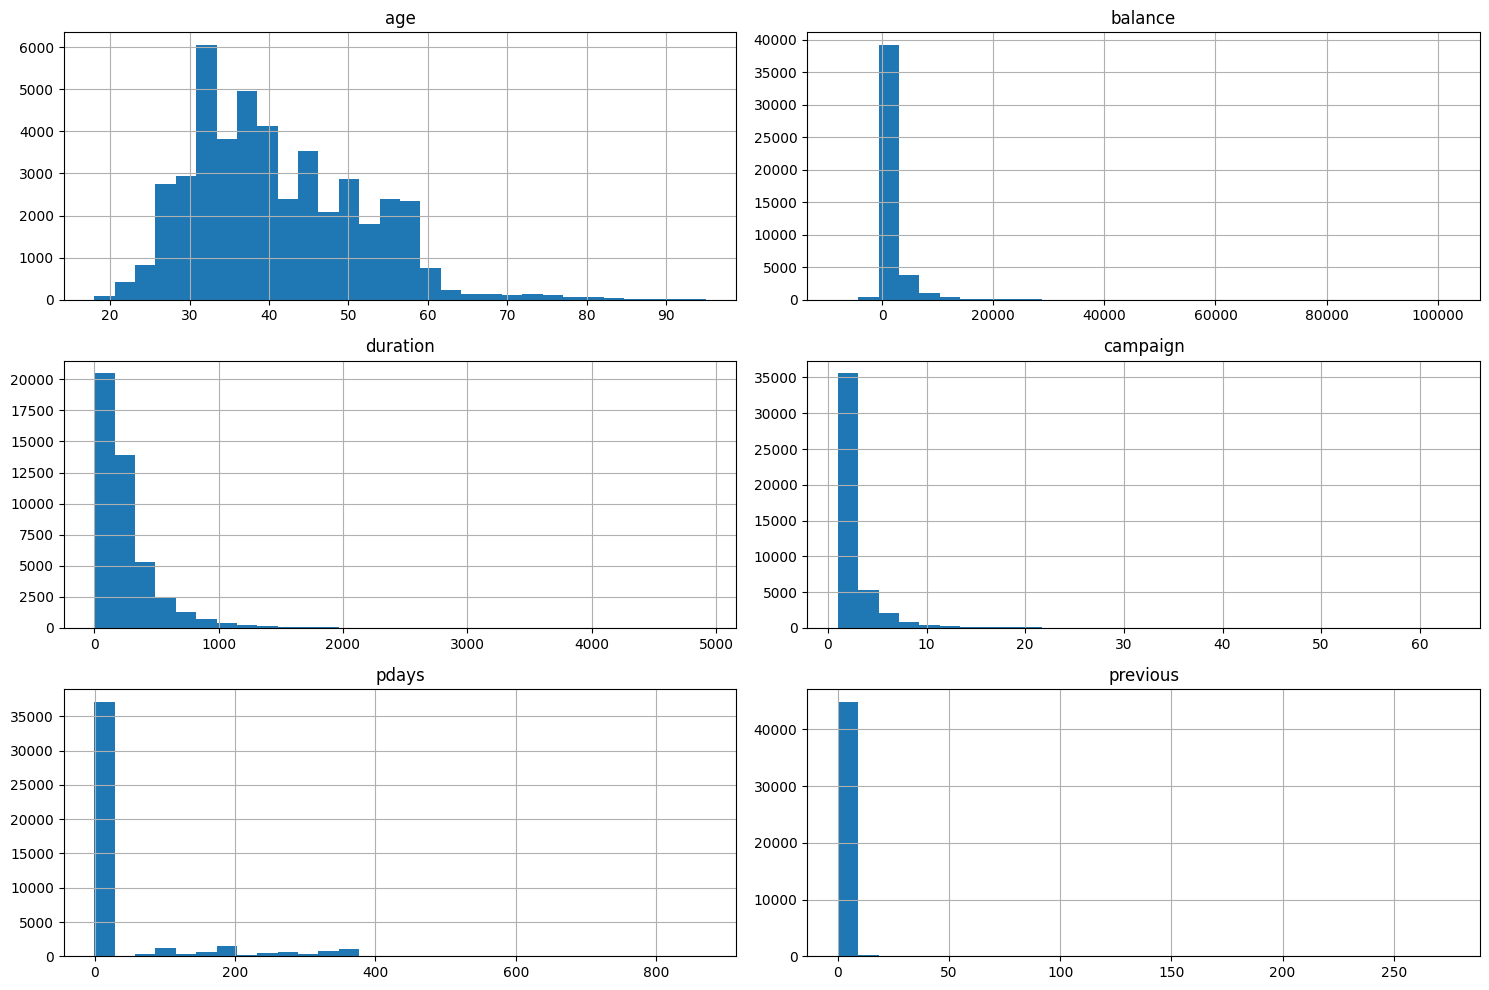

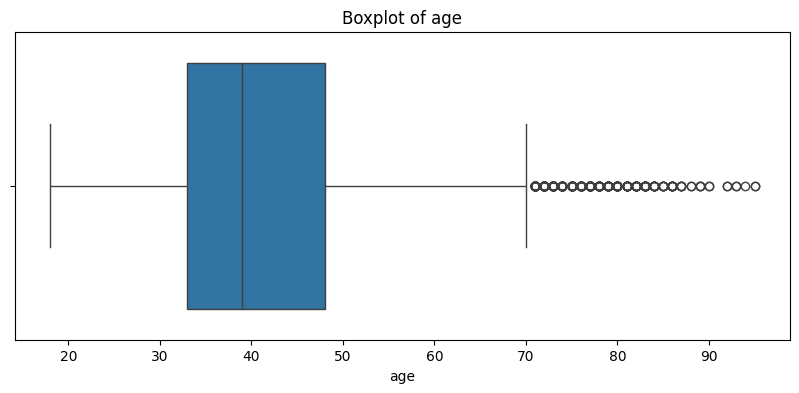

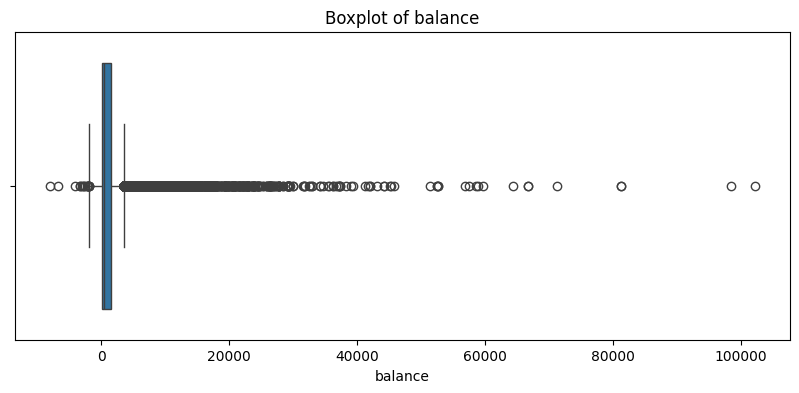

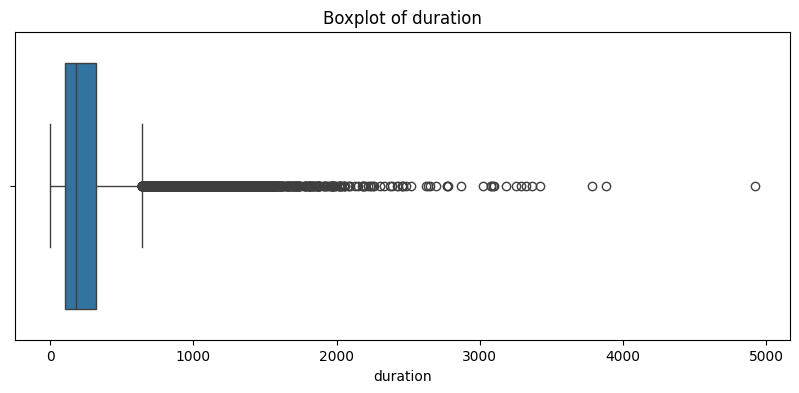

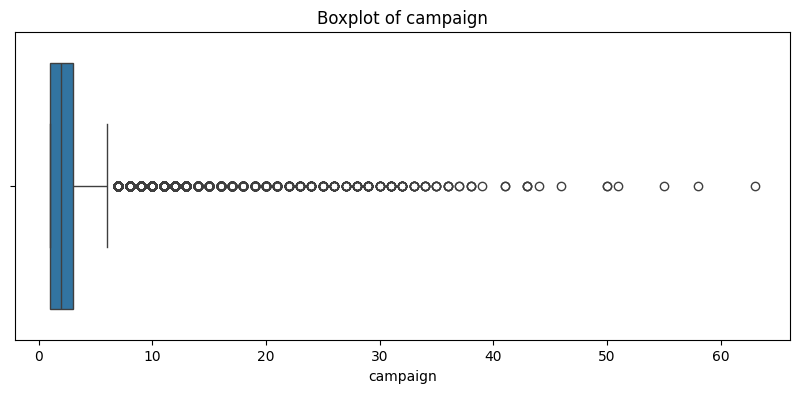

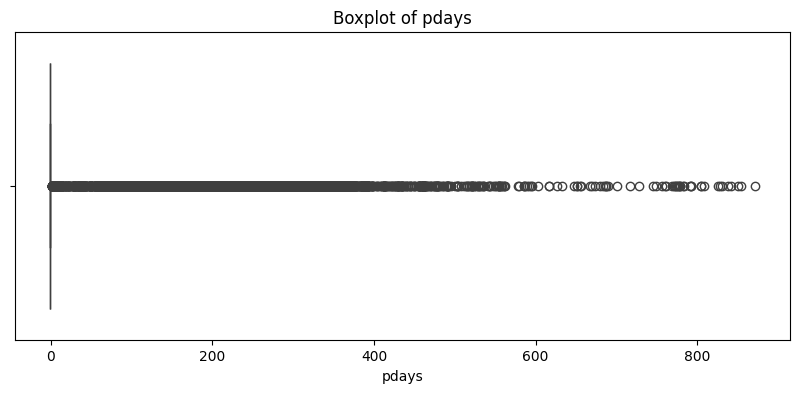

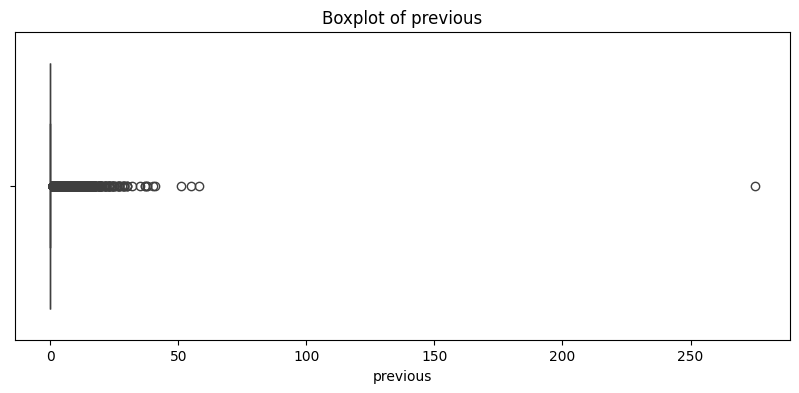

In [ ]:
# Select only numerical columns
numerical_cols = Bn.select_dtypes(include=np.number).columns

# Display descriptive statistics for numerical columns
display(Bn[numerical_cols].describe())

# Create histograms for each numerical column
Bn[numerical_cols].hist(bins=30, figsize=(15, 10))
plt.tight_layout()
plt.show()

# Create boxplots for each numerical column
for col in numerical_cols:
    plt.figure(figsize=(10, 4))
    sns.boxplot(x=Bn[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [ ]:
display(Bn.head())
print(Bn.dtypes)

,age,job,marital,education,default,balance,housing,loan,duration,campaign,pdays,previous,y
0,58,management,married,tertiary,no,2143,yes,no,261,1,-1,0,no
1,44,technician,single,secondary,no,29,yes,no,151,1,-1,0,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,76,1,-1,0,no
3,47,blue-collar,married,secondary,no,1506,yes,no,92,1,-1,0,no
4,33,blue-collar,single,secondary,no,1,no,no,198,1,-1,0,no


age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
duration      int64
campaign      int64
pdays         int64
previous      int64
y            object
dtype: object


Value counts for column ['job']:


,count
job,
blue-collar,10020
management,9458
technician,7597
admin.,5171
services,4154
retired,2264
self-employed,1579
entrepreneur,1487
unemployed,1303


--------------------
Value counts for column ['marital']:


,count
marital,
married,27214
single,12790
divorced,5207


--------------------
Value counts for column ['education']:


...

--------------------
Value counts for column ['loan']:


,count
loan,
no,37967
yes,7244


--------------------
Value counts for column ['y']:


,count
y,
no,39922
yes,5289


--------------------


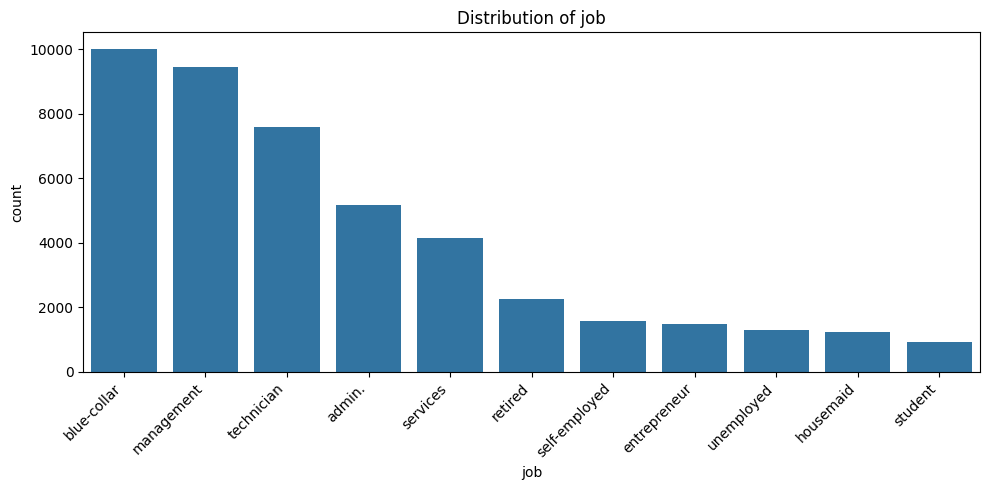

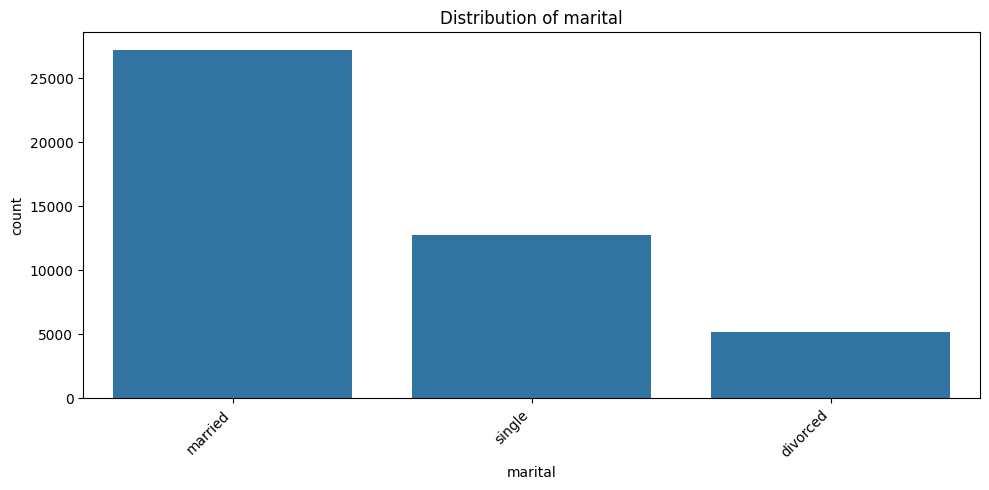

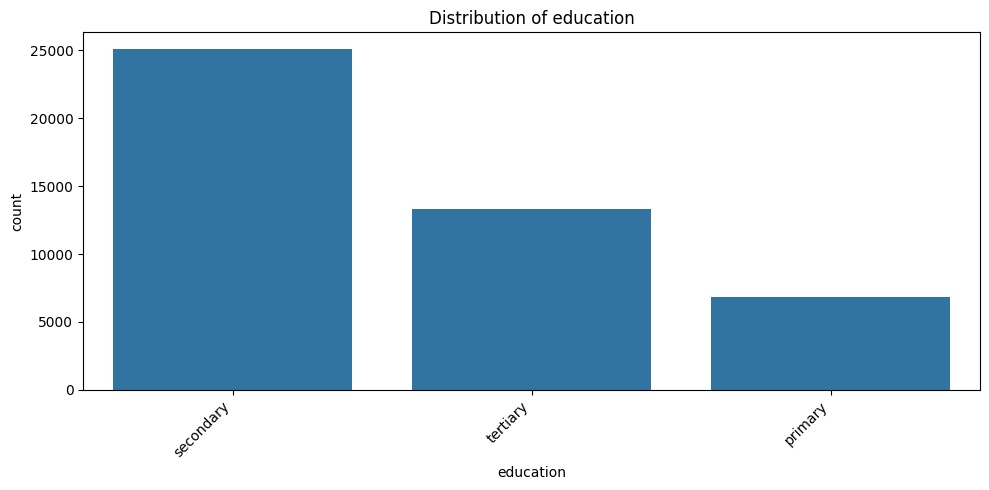

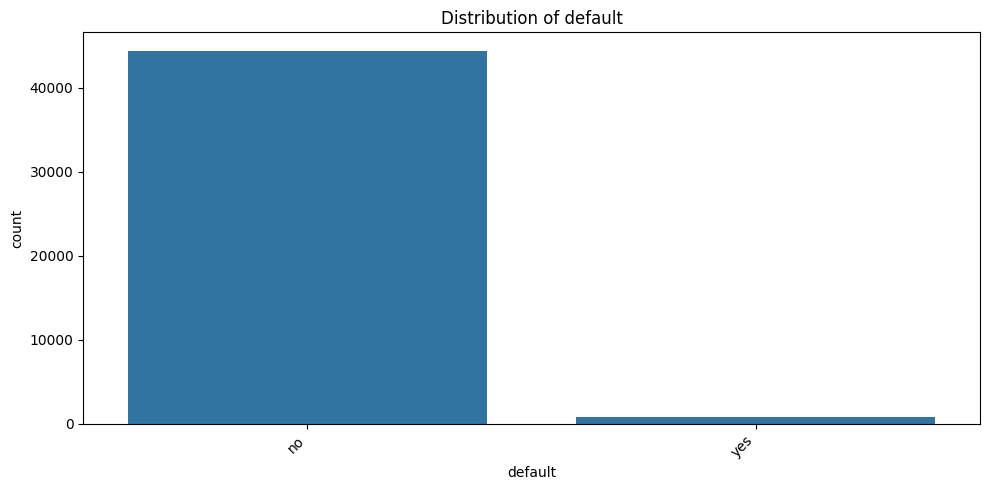

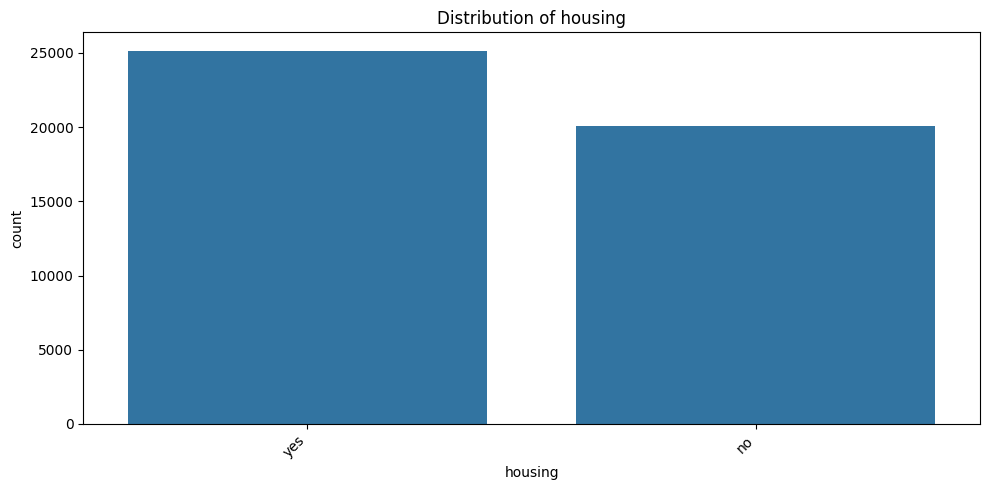

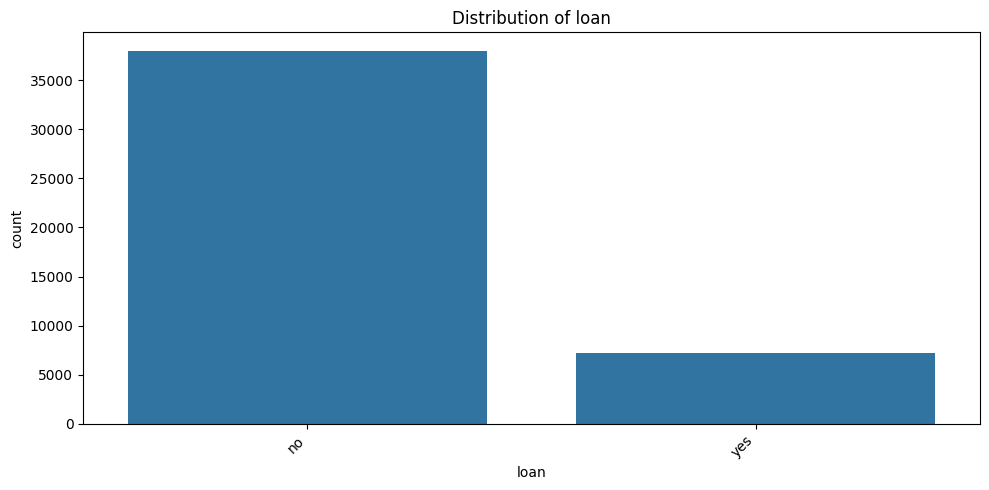

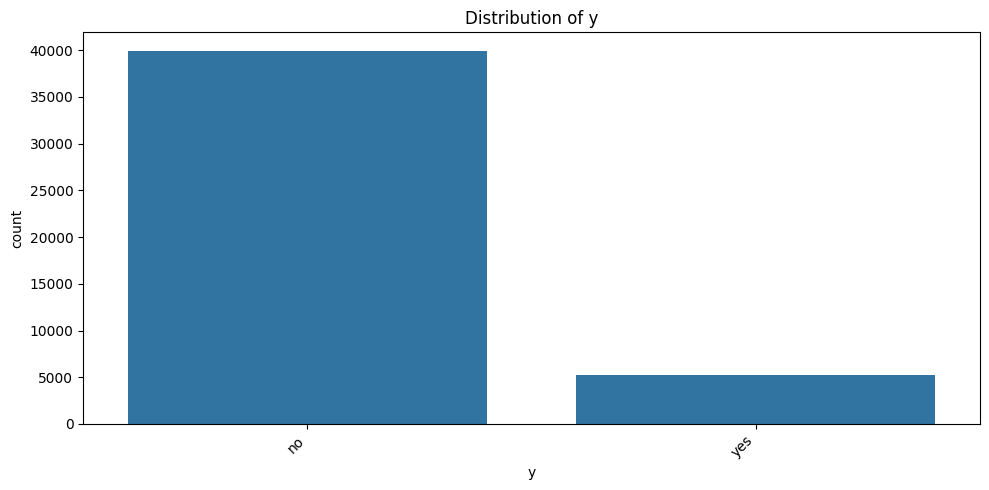

In [ ]:
# Select only categorical columns
categorical_cols = Bn.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"Value counts for column ['{col}']:")
    display(Bn[col].value_counts())
    print("-" * 20)

# Create bar plots for each categorical column
for col in categorical_cols:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=Bn, x=col, order=Bn[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

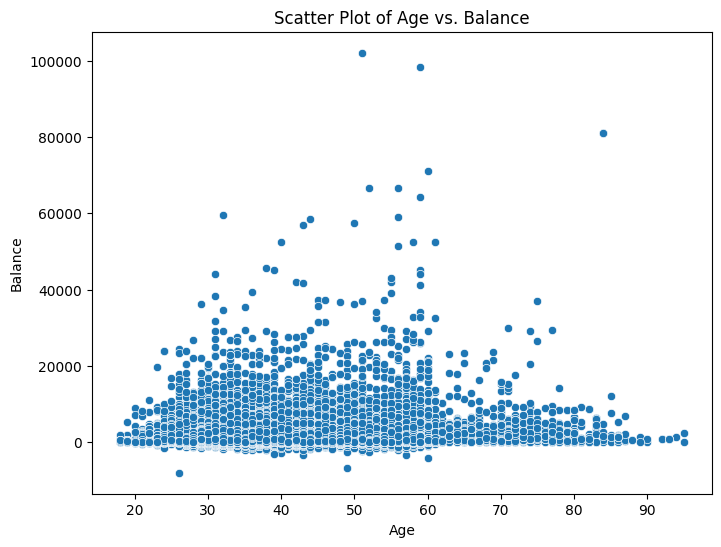

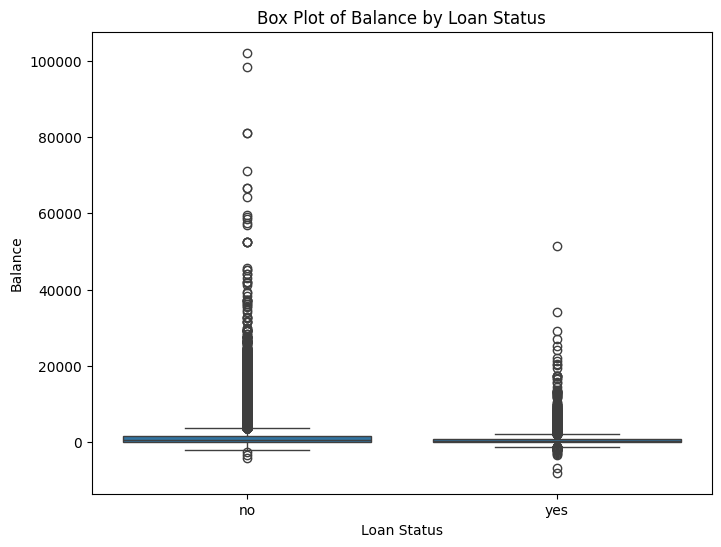

In [ ]:
# Visualize relationships between numerical features (example: age vs balance)
plt.figure(figsize=(8, 6))
sns.scatterplot(data=Bn, x='age', y='balance')
plt.title('Scatter Plot of Age vs. Balance')
plt.xlabel('Age')
plt.ylabel('Balance')
plt.show()

# Visualize relationships between numerical and categorical features (example: balance vs loan)
plt.figure(figsize=(8, 6))
sns.boxplot(data=Bn, x='loan', y='balance')
plt.title('Box Plot of Balance by Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('Balance')
plt.show()

In [ ]:
categorical_cols = Bn.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"Unique values in column ['{col}']:")
    print(Bn[col].unique())
    print("-" * 20)

Unique values in column ['job']:
['management' 'technician' 'entrepreneur' 'blue-collar' 'retired' 'admin.'
 'services' 'self-employed' 'unemployed' 'housemaid' 'student']
--------------------
Unique values in column ['marital']:
['married' 'single' 'divorced']
--------------------
Unique values in column ['education']:
['tertiary' 'secondary' 'primary']
--------------------
Unique values in column ['default']:
['no' 'yes']
--------------------
Unique values in column ['housing']:
['yes' 'no']
--------------------
Unique values in column ['loan']:
['no' 'yes']
--------------------
Unique values in column ['y']:
['no' 'yes']
--------------------


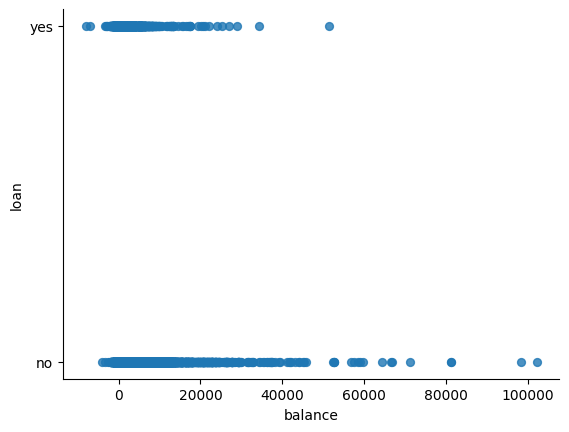

In [ ]:
Bn.plot(kind='scatter', x='balance', y='loan', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)
plt.show()

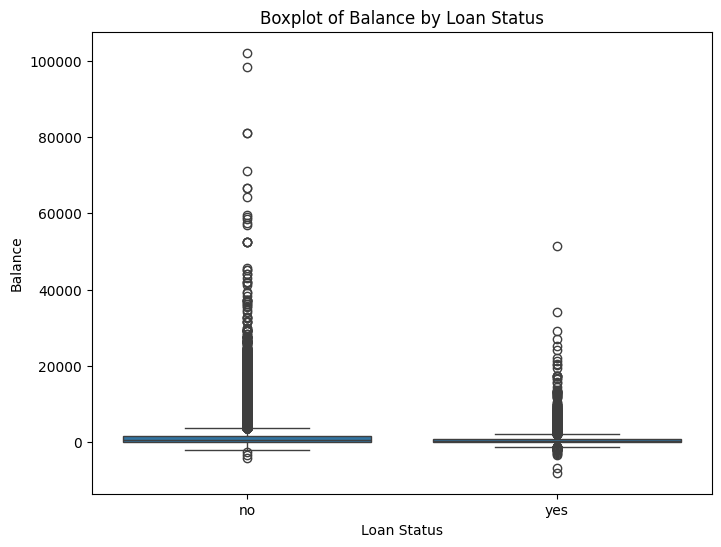

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='loan', y='balance', data=Bn)
plt.title('Boxplot of Balance by Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('Balance')
plt.show()

In [ ]:
Bn

,age,job,marital,education,default,balance,housing,loan,duration,campaign,pdays,previous,y
0,58,management,married,tertiary,no,2143,yes,no,261,1,-1,0,no
1,44,technician,single,secondary,no,29,yes,no,151,1,-1,0,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,76,1,-1,0,no
3,47,blue-collar,married,secondary,no,1506,yes,no,92,1,-1,0,no
4,33,blue-collar,single,secondary,no,1,no,no,198,1,-1,0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,977,3,-1,0,yes
45207,71,retired,divorced,primary,no,1729,no,no,456,2,-1,0,yes
45208,72,retired,married,secondary,no,5715,no,no,1127,5,184,3,yes
45209,57,blue-collar,married,secondary,no,668,no,no,508,4,-1,0,no


In [ ]:
#!pip install ydata-profiling

In [ ]:
# Identify quasi-constant features
quasi_constant_features = []
for col in Bn.columns:
    # Calculate the percentage of the most frequent value
    most_frequent_percentage = (Bn[col].value_counts(normalize=True).max()) * 100
    if most_frequent_percentage > 95:
        quasi_constant_features.append(col)

# Drop quasi-constant features
Bn_filtered = Bn.drop(columns=quasi_constant_features)

print(f"Original number of features: {Bn.shape[1]}")
print(f"Quasi-constant features removed: {quasi_constant_features}")
print(f"Number of features after filtering: {Bn_filtered.shape[1]}")

# Display the first few rows of the filtered DataFrame
display(Bn_filtered.head())

Original number of features: 13
Quasi-constant features removed: ['default']
Number of features after filtering: 12


,age,job,marital,education,balance,housing,loan,duration,campaign,pdays,previous,y
0,58,management,married,tertiary,2143,yes,no,261,1,-1,0,no
1,44,technician,single,secondary,29,yes,no,151,1,-1,0,no
2,33,entrepreneur,married,secondary,2,yes,yes,76,1,-1,0,no
3,47,blue-collar,married,secondary,1506,yes,no,92,1,-1,0,no
4,33,blue-collar,single,secondary,1,no,no,198,1,-1,0,no


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Identify categorical columns to encode
categorical_cols_to_encode = [col for col in Bn.select_dtypes(include='object').columns if col not in ['job', 'marital', 'education']]

# Apply Label Encoding to the selected categorical columns
label_encoders = {}
for col in categorical_cols_to_encode:
    label_encoders[col] = LabelEncoder()
    Bn[col] = label_encoders[col].fit_transform(Bn[col])

print("Label encoding applied to the following columns:")
print(categorical_cols_to_encode)
display(Bn.head())

Label encoding applied to the following columns:
['default', 'housing', 'loan', 'y']


,age,job,marital,education,default,balance,housing,loan,duration,campaign,pdays,previous,y
0,58,management,married,tertiary,0,2143,1,0,261,1,-1,0,0
1,44,technician,single,secondary,0,29,1,0,151,1,-1,0,0
2,33,entrepreneur,married,secondary,0,2,1,1,76,1,-1,0,0
3,47,blue-collar,married,secondary,0,1506,1,0,92,1,-1,0,0
4,33,blue-collar,single,secondary,0,1,0,0,198,1,-1,0,0


In [ ]:
# Apply one-hot encoding to 'job', 'marital', and 'education' columns
Bn_encoded = pd.get_dummies(Bn, columns=['job', 'marital', 'education'], drop_first=True)

# Display the first few rows of the encoded DataFrame
display(Bn_encoded.head())

,age,default,balance,housing,loan,duration,campaign,pdays,previous,y,...,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,marital_married,marital_single,education_secondary,education_tertiary
0,58,0,2143,1,0,261,1,-1,0,0,...,False,False,False,False,False,False,True,False,False,True
1,44,0,29,1,0,151,1,-1,0,0,...,False,False,False,False,True,False,False,True,True,False
2,33,0,2,1,1,76,1,-1,0,0,...,False,False,False,False,False,False,True,False,True,False
3,47,0,1506,1,0,92,1,-1,0,0,...,False,False,False,False,False,False,True,False,True,False
4,33,0,1,0,0,198,1,-1,0,0,...,False,False,False,False,False,False,False,True,True,False


In [ ]:
Bn_encoded.columns

Index(['age', 'default', 'balance', 'housing', 'loan', 'duration', 'campaign',
       'pdays', 'previous', 'y', 'job_blue-collar', 'job_entrepreneur',
       'job_housemaid', 'job_management', 'job_retired', 'job_self-employed',
       'job_services', 'job_student', 'job_technician', 'job_unemployed',
       'marital_married', 'marital_single', 'education_secondary',
       'education_tertiary'],
      dtype='object')

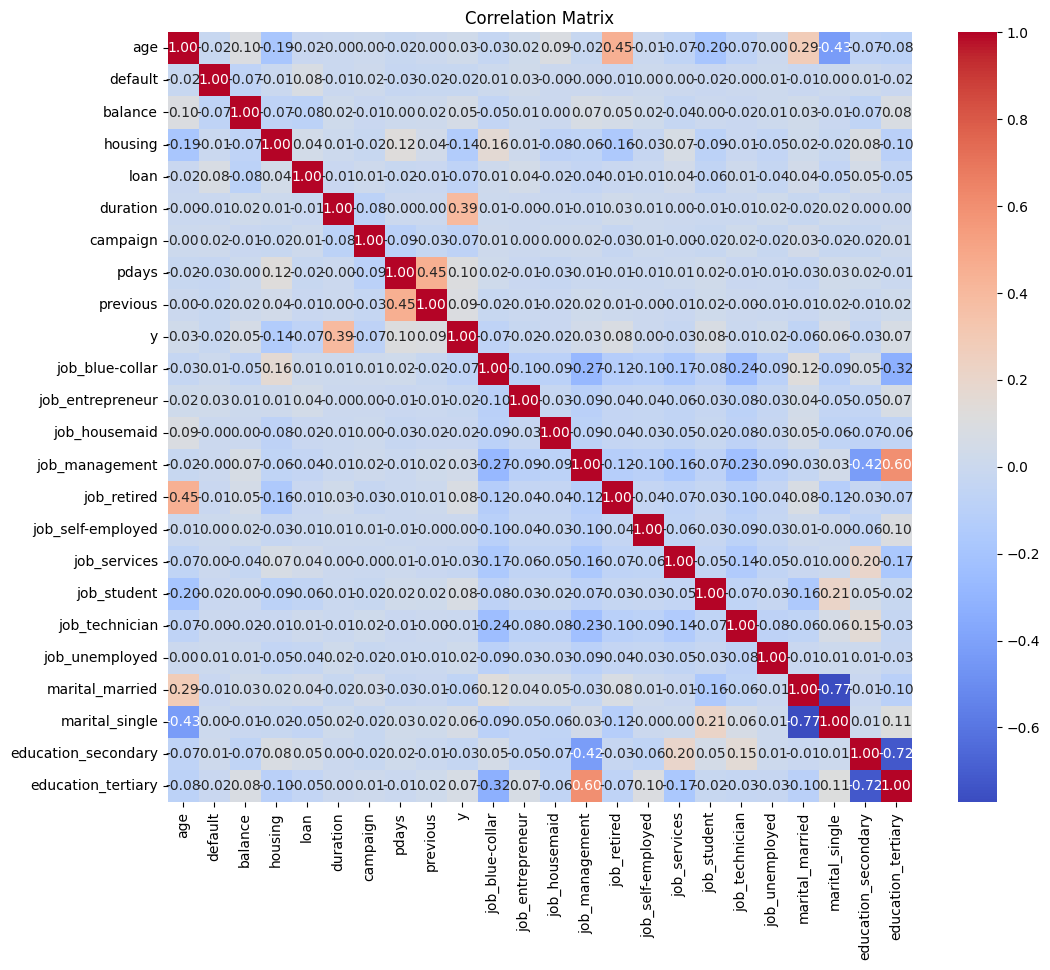

In [ ]:
# Calculate the correlation matrix
corr_matrix = Bn_encoded.corr()

# Plot the correlation matrix as a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

# data spilit with loan Target


In [ ]:
X_loan = Bn_encoded.drop('loan', axis=1)
y_loan = Bn_encoded['loan']
X_train_loan, X_test_loan, y_train_loan, y_test_loan = train_test_split(X_loan, y_loan, test_size=0.25, random_state=42)

print("Shape of X_train:", X_train_loan.shape)
print("Shape of X_test:", X_test_loan.shape)
print("Shape of y_train:", y_train_loan.shape)
print("Shape of y_test:", y_test_loan.shape)

Shape of X_train: (33908, 23)
Shape of X_test: (11303, 23)
Shape of y_train: (33908,)
Shape of y_test: (11303,)


In [ ]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE to the training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_loan, y_train_loan)

print("Shape of X_train after SMOTE:", X_train_smote.shape)
print("Shape of y_train after SMOTE:", y_train_smote.shape)

# Check the distribution of the target variable after SMOTE
print("\nDistribution of 'y' in y_train_smote:")
print(y_train_smote.value_counts())

Shape of X_train after SMOTE: (56882, 23)
Shape of y_train after SMOTE: (56882,)

Distribution of 'y' in y_train_smote:
loan
0    28441
1    28441
Name: count, dtype: int64


# data spilit with y target

In [ ]:
# Split data into training and testing sets
X = Bn_encoded.drop('y', axis=1)
y = Bn_encoded['y']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (33908, 23)
Shape of X_test: (11303, 23)
Shape of y_train: (33908,)
Shape of y_test: (11303,)


# scaling data of loan target

In [ ]:
# Apply RobustScaler to the numerical features
numerical_cols = X_train_smote.select_dtypes(include=np.number).columns
scaler = RobustScaler()

X_train_smote[numerical_cols] = scaler.fit_transform(X_train_smote[numerical_cols])
X_test_loan[numerical_cols] = scaler.transform(X_test_loan[numerical_cols])

display(X_train.head())

,age,default,balance,housing,loan,duration,campaign,pdays,previous,job_blue-collar,...,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,marital_married,marital_single,education_secondary,education_tertiary
41626,52,0,118,0,0,105,1,-1,0,False,...,False,False,False,False,False,False,True,False,True,False
31347,28,0,459,0,0,83,13,-1,0,False,...,False,False,False,True,False,False,False,True,True,False
22563,36,0,156,0,0,122,1,-1,0,False,...,False,False,False,False,False,False,False,True,False,True
37243,55,0,323,1,1,200,1,-1,0,False,...,False,False,False,False,False,False,True,False,False,True
32259,38,0,904,1,0,361,1,339,1,False,...,False,False,True,False,False,False,False,False,True,False


# scaling datd to resist outlier


In [ ]:
# Apply RobustScaler to the numerical features
numerical_cols = X_train.select_dtypes(include=np.number).columns
scaler = RobustScaler()

X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

display(X_train.head())

,age,default,balance,housing,loan,duration,campaign,pdays,previous,job_blue-collar,...,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,marital_married,marital_single,education_secondary,education_tertiary
41626,0.866667,0.0,-0.240059,-1.0,0.0,-0.348837,-0.5,0.0,0.0,False,...,False,False,False,False,False,False,True,False,True,False
31347,-0.733333,0.0,0.011046,-1.0,0.0,-0.451163,5.5,0.0,0.0,False,...,False,False,False,True,False,False,False,True,True,False
22563,-0.200000,0.0,-0.212077,-1.0,0.0,-0.269767,-0.5,0.0,0.0,False,...,False,False,False,False,False,False,False,True,False,True
37243,1.066667,0.0,-0.089102,0.0,1.0,0.093023,-0.5,0.0,0.0,False,...,False,False,False,False,False,False,True,False,False,True
32259,-0.066667,0.0,0.338733,0.0,0.0,0.841860,-0.5,340.0,1.0,False,...,False,False,True,False,False,False,False,False,True,False


# Train model

In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

# CM for Y target

In [ ]:
class Train ():
  def __init__(self, X_train, X_test, y_train, y_test):
    self.X_train = X_train
    self.X_test = X_test
    self.y_train = y_train
    self.y_test = y_test
  def dt(self):
    # Create a Decision Tree classifier
    dt_classifier = DecisionTreeClassifier()
    dt_classifier.fit(self.X_train, self.y_train)
    y_pred = dt_classifier.predict(self.X_test)
    accuracy = accuracy_score(self.y_test, y_pred)
    print(f"Accuracy: {accuracy}")
    print(classification_report(self.y_test, y_pred))
    return y_pred
  def svc(self):
    # Create an SVM classifier
    svm_classifier = SVC()
    svm_classifier.fit(self.X_train, self.y_train)
    y_pred = svm_classifier.predict(self.X_test)
    accuracy = accuracy_score(self.y_test, y_pred)
    print(f"Accuracy: {accuracy}")
    print(classification_report(self.y_test, y_pred))
    return y_pred
  def rf(self):
    # Create a Random Forest classifier
    rf_classifier = RandomForestClassifier()
    rf_classifier.fit(self.X_train, self.y_train)
    y_pred = rf_classifier.predict(self.X_test)
    accuracy = accuracy_score(self.y_test, y_pred)
    print(f"Accuracy: {accuracy}")
    print(classification_report(self.y_test, y_pred))
    return y_pred
  def ada(self):
    # Create an AdaBoost classifier
    ada_classifier = AdaBoostClassifier()
    ada_classifier.fit(self.X_train, self.y_train)
    y_pred = ada_classifier.predict(self.X_test) # Removed self.y_test
    accuracy = accuracy_score(self.y_test, y_pred)
    print(f"Accuracy: {accuracy}")
    print(classification_report(self.y_test, y_pred))
    return y_pred

Accuracy: 0.8467663452180837
              precision    recall  f1-score   support

           0       0.92      0.91      0.91      9950
           1       0.37      0.41      0.39      1353

    accuracy                           0.85     11303
   macro avg       0.65      0.66      0.65     11303
weighted avg       0.85      0.85      0.85     11303



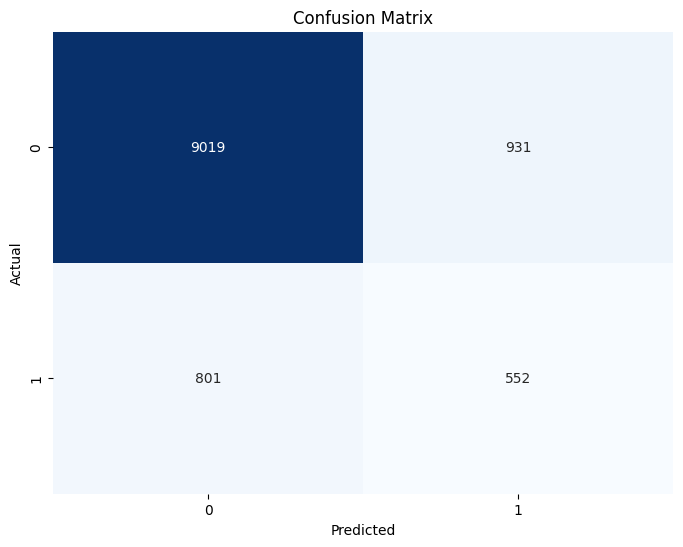

In [ ]:
tTree = Train(X_train, X_test, y_train, y_test)
y_pred = tTree.dt() # Capture the predictions in y_pred
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming you have already trained the stacked model and made predictions
# y_test contains the true labels and y_pred contains the predicted labels

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Accuracy: 0.8802972662125099
              precision    recall  f1-score   support

           0       0.88      1.00      0.94      9950
           1       0.00      0.00      0.00      1353

    accuracy                           0.88     11303
   macro avg       0.44      0.50      0.47     11303
weighted avg       0.77      0.88      0.82     11303



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


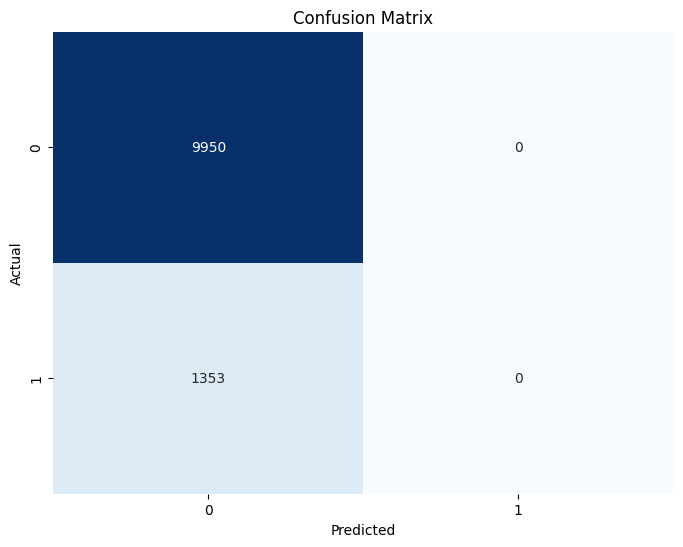

In [ ]:
tSVC = Train(X_train, X_test, y_train, y_test)
y_pred = tSVC.svc() # Capture the predictions in y_pred
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming you have already trained the stacked model and made predictions
# y_test contains the true labels and y_pred contains the predicted labels

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Accuracy: 0.8932141909227639
              precision    recall  f1-score   support

           0       0.91      0.97      0.94      9950
           1       0.60      0.34      0.43      1353

    accuracy                           0.89     11303
   macro avg       0.76      0.65      0.69     11303
weighted avg       0.88      0.89      0.88     11303



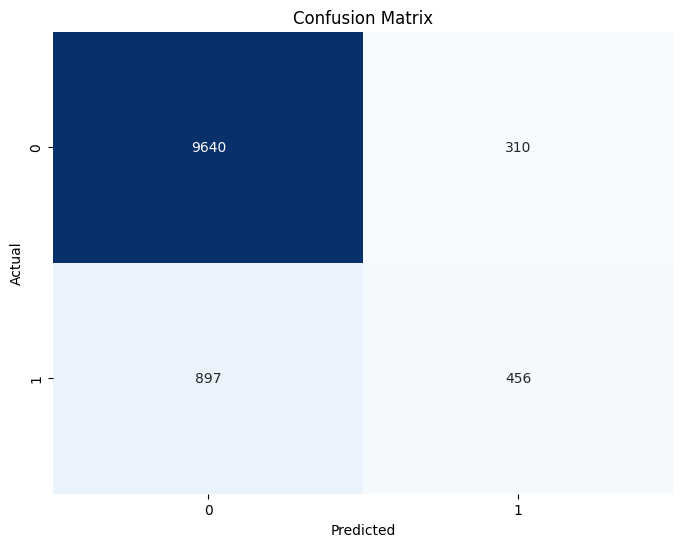

In [ ]:
tRF = Train(X_train, X_test, y_train, y_test)
y_pred = tRF.rf() # Capture the predictions in y_pred
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming you have already trained the stacked model and made predictions
# y_test contains the true labels and y_pred contains the predicted labels

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Accuracy: 0.8879058656993718
              precision    recall  f1-score   support

           0       0.91      0.97      0.94      9950
           1       0.57      0.27      0.37      1353

    accuracy                           0.89     11303
   macro avg       0.74      0.62      0.65     11303
weighted avg       0.87      0.89      0.87     11303



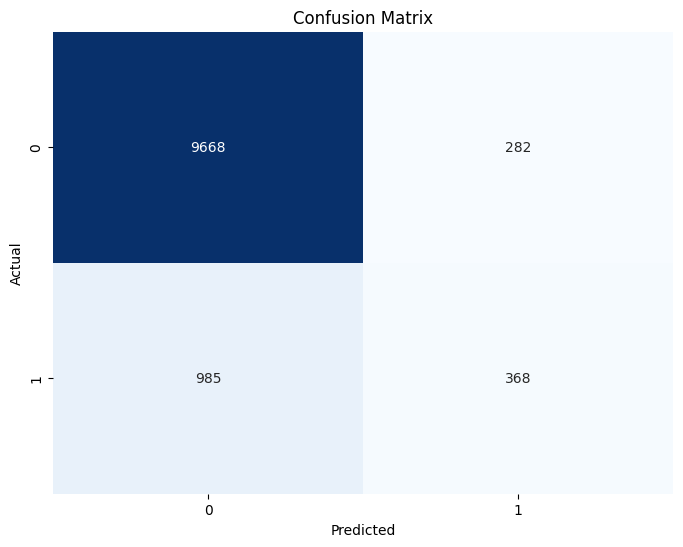

In [ ]:
tADA = Train(X_train, X_test, y_train, y_test)
y_pred = tADA.ada() # Capture the predictions in y_pred
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming you have already trained the stacked model and made predictions
# y_test contains the true labels and y_pred contains the predicted labels

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


AdaBoost Model with SMOTE-d data:
Accuracy: 0.691320888259754
              precision    recall  f1-score   support

           0       0.86      0.76      0.81      9526
           1       0.20      0.33      0.25      1777

    accuracy                           0.69     11303
   macro avg       0.53      0.54      0.53     11303
weighted avg       0.76      0.69      0.72     11303



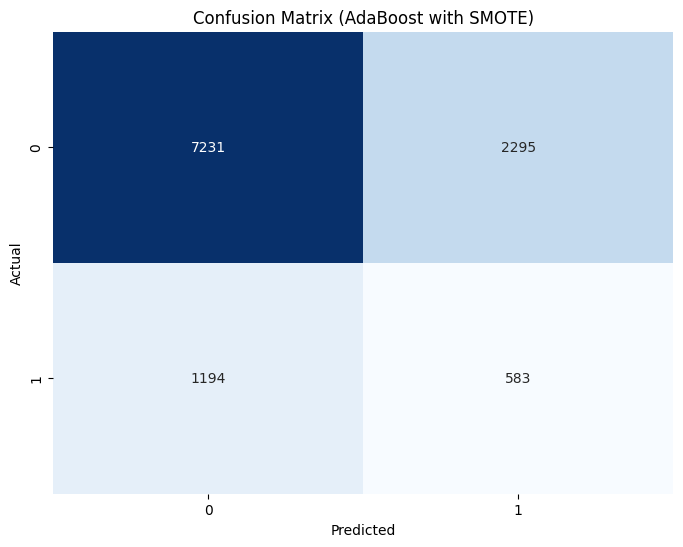

In [ ]:
# Instantiate the Train class with SMOTE-d data
tADA_smote = Train(X_train_smote, X_test_loan, y_train_smote, y_test_loan)

# Train and evaluate AdaBoost model
print("\nAdaBoost Model with SMOTE-d data:")
y_pred_ada_smote = tADA_smote.ada()

# Calculate and plot the confusion matrix for AdaBoost
cm_ada_smote = confusion_matrix(y_test_loan, y_pred_ada_smote)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_ada_smote, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (AdaBoost with SMOTE)')
plt.show()


Random Forest Model with SMOTE-d data:
Accuracy: 0.7920905954171459
              precision    recall  f1-score   support

           0       0.85      0.91      0.88      9526
           1       0.25      0.16      0.20      1777

    accuracy                           0.79     11303
   macro avg       0.55      0.54      0.54     11303
weighted avg       0.76      0.79      0.77     11303



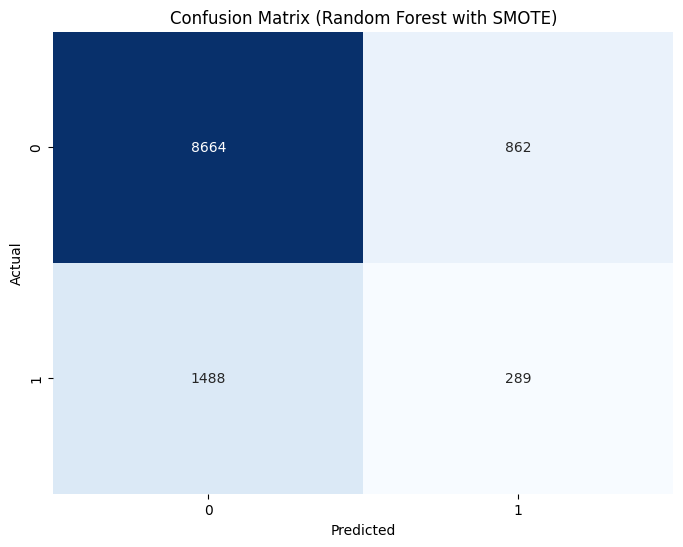

In [ ]:
# Instantiate the Train class with SMOTE-d data
tRF_smote = Train(X_train_smote, X_test_loan, y_train_smote, y_test_loan)

# Train and evaluate Random Forest model
print("\nRandom Forest Model with SMOTE-d data:")
y_pred_rf_smote = tRF_smote.rf()

# Calculate and plot the confusion matrix for Random Forest
cm_rf_smote = confusion_matrix(y_test_loan, y_pred_rf_smote)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf_smote, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Random Forest with SMOTE)')
plt.show()

Decision Tree Model with SMOTE-d data:
Accuracy: 0.7219322303813147
              precision    recall  f1-score   support

           0       0.86      0.80      0.83      9526
           1       0.22      0.29      0.25      1777

    accuracy                           0.72     11303
   macro avg       0.54      0.55      0.54     11303
weighted avg       0.76      0.72      0.74     11303



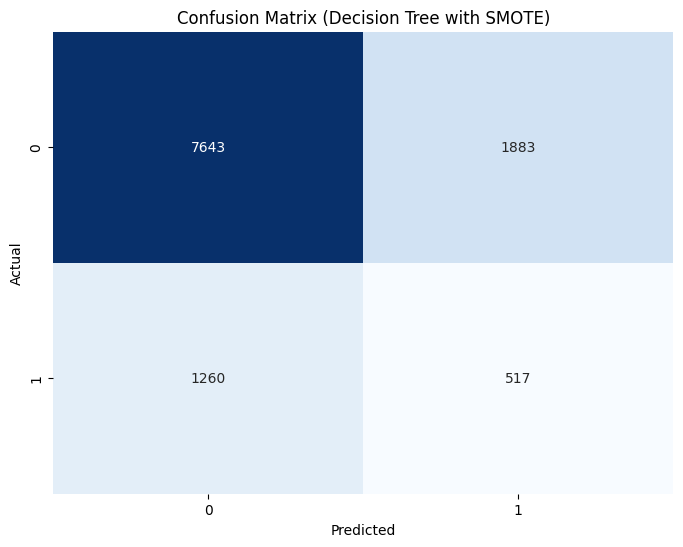

In [ ]:
# Instantiate the Train class with SMOTE-d data
tTree_smote = Train(X_train_smote, X_test_loan, y_train_smote, y_test_loan)

# Train and evaluate Decision Tree model
print("Decision Tree Model with SMOTE-d data:")
y_pred_dt_smote = tTree_smote.dt()

# Calculate and plot the confusion matrix for Decision Tree
cm_dt_smote = confusion_matrix(y_test_loan, y_pred_dt_smote)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt_smote, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Decision Tree with SMOTE)')
plt.show()

In [ ]:
#بياخد وقت ف الرنتايم بيوصل لساعتين و ازيد
from sklearn.ensemble import StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

def train_stacked_model(X_train, X_test, y_train, y_test):
    """
    Trains a stacked model and evaluates its performance.

    Args:
        X_train: Training features.
        X_test: Testing features.
        y_train: Training target.
        y_test: Testing target.

    Returns:
        A tuple containing accuracy score, classification report, and predictions on the test set.
    """

    # Define base learners
    base_learners = [
        ('dt', DecisionTreeClassifier(max_depth=10, min_samples_split=5, random_state=42)),
        ('svc', SVC(probability=True, random_state=42)), # SVC needs probability=True for stacking
        ('rf', RandomForestClassifier(random_state=42))
    ]

    # Define meta-classifier
    meta_classifier = LogisticRegression(random_state= 42)
    # Create stacking classifier
    stacked_model = StackingClassifier(estimators=base_learners, final_estimator=meta_classifier, cv=3)

    # Train the stacked model
    stacked_model.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred_stack = stacked_model.predict(X_test)

    # Evaluate the model
    accuracy = accuracy_score(y_test, y_pred_stack)
    report = classification_report(y_test, y_pred_stack)

    return accuracy, report, y_pred_stack

# Train and evaluate the stacked model
accuracy, report, y_pred_stack = train_stacked_model(X_train_smote, X_test_loan, y_train_smote, y_test_loan)

# Print the results
print("Accuracy:", accuracy)
print("Classification Report:\n", report)

Accuracy: 0.7819163054056445
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.89      0.87      9526
           1       0.24      0.18      0.20      1777

    accuracy                           0.78     11303
   macro avg       0.55      0.54      0.54     11303
weighted avg       0.76      0.78      0.77     11303

